In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import cross_val_score

In [ ]:
df=pd.read_csv('/content/messy_ecommerce_sales_data.csv')

In [ ]:
df.head() # Check the first five rows of the Dataset

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
0,100,Customer_100,ORD-41285,11/22/2024,Blender,Home,3,38,Cash on Delivery,Shipped,114.00
1,101,Customer_101,ORD-35783,7/5/2025,Smartphone,Electronics,2,abd,PayPal,Processing,NaN
2,102,Customer_102,ORD-84355,12/23/2024,Tennis Racket,Sports,1,389.05,PayPal,Delivered,389.05
3,103,Customer_103,ORD-57811,3/19/2025,Science,Books,5,233.92,PayPal,Processing,1169.60
4,104,Customer_104,ORD-93614,10/20/2025,Biography,Books,1,552.51,Cash on Delivery,Processing,552.51


In [ ]:
df.info() # Check the dataset information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              103 non-null    int64  
 1    Customer_Name  103 non-null    object 
 2   Order_ID        103 non-null    object 
 3   Order_Date      103 non-null    object 
 4   Product         103 non-null    object 
 5    Category       95 non-null     object 
 6   Quantity        98 non-null     object 
 7   Price           98 non-null     object 
 8   Payment_Method  103 non-null    object 
 9   Status          103 non-null    object 
 10  Total           89 non-null     float64
dtypes: float64(1), int64(1), object(9)
memory usage: 9.0+ KB


In [ ]:
df.isnull().sum() # Check the null values

,0
ID,0
Customer_Name,0
Order_ID,0
Order_Date,0
Product,0
Category,8
Quantity,5
Price,5
Payment_Method,0
Status,0


In [ ]:
df[' Category']=df[' Category'].fillna(df[' Category'].mode().iloc[0]) # Fill missing values in 'Category' column with the most frequent category

df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce') #Convert 'Quantity' column to numeric type
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].mean()) #Fill missing values in 'Quantity' with the mean of the column
df['Quantity'] = df['Quantity'].astype(int) #Convert 'Quantity' to integer type after filling missing values

df['Price'] = pd.to_numeric(df['Price'], errors='coerce') #Convert 'Price' column to numeric type
df['Price'] = df['Price'].fillna(df['Price'].mean()) #Fill missing values in 'Price' with the mean of the column
df['Price'] = df['Price'].astype(int) # Convert 'Price' to integer type after filling missing values

In [ ]:
df.drop(['ID', ' Customer_Name', 'Order_ID'], axis=1,inplace=True) #Drop unnecessry Columns

In [ ]:
#Convert 'Order_Date' column to datetime format
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce', format='mixed')
df['Year']=df['Order_Date'].dt.year.fillna(0).astype(int) # Extract year from 'Order_Date', fill missing with 0, convert to int
df['Month']=df['Order_Date'].dt.month.fillna(0).astype(int) #Extract month from 'Order_Date', fill missing with 0, convert to int
df['Day']=df['Order_Date'].dt.day.fillna(0).astype(int) #Extract day from 'Order_Date', fill missing with 0, convert to int
df.drop('Order_Date',axis=1,inplace=True) #Drop the original 'Order_Date' column as it is now redundant


In [ ]:
negatives = df[(df['Quantity'] < 0) | (df['Price'] < 0) | (df['Total'] < 0)] #Identify rows where any of the numerical columns have negative values
negatives
df = df[(df['Quantity'] >= 0) & (df['Price'] >= 0) & (df['Total'] >= 0)] #Remove rows where any of these columns have negative values


In [ ]:
df.describe() #Statistical Summary

,Quantity,Price,Total,Year,Month,Day
count,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000
mean,2.988372,514.011628,1546.396744,2024.767442,6.697674,14.790698
std,1.522337,262.983717,1179.170897,0.501161,3.498133,8.873114
min,1.000000,38.000000,40.950000,2023.000000,1.000000,1.000000
25%,2.000000,268.250000,645.263000,2025.000000,4.000000,6.500000
50%,3.000000,534.500000,1191.100000,2025.000000,7.000000,14.500000
75%,4.000000,734.500000,2232.157500,2025.000000,10.000000,22.000000
max,5.000000,944.000000,4722.700000,2025.000000,12.000000,31.000000


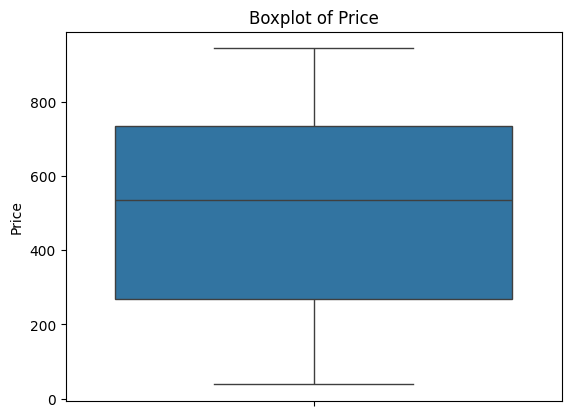

In [ ]:
sns.boxplot(y=df['Price']) #Visualize the boxplot of Price by Seaborn
plt.title('Boxplot of Price') #Title of the boxplot
plt.show() #Display of the boxplot

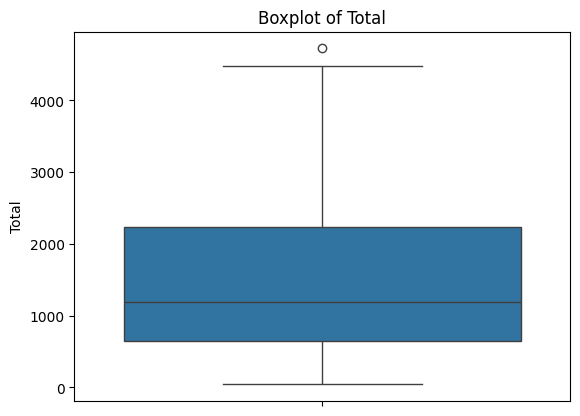

In [ ]:
sns.boxplot(y=df['Total']) #visualize the boxplot of Total by Seaborn
plt.title('Boxplot of Total') #Title of the boxplot
plt.show() #Display of the boxplot

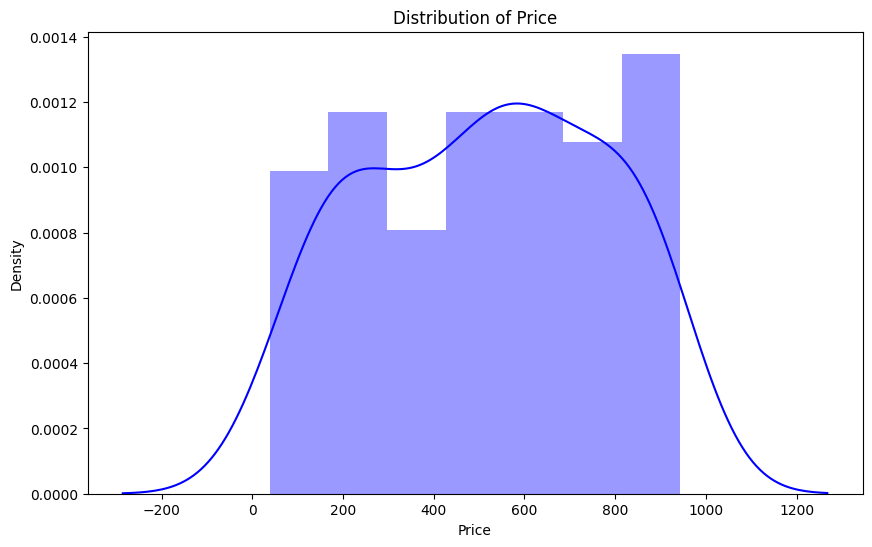

In [ ]:
plt.figure(figsize=(10,6)) #Set the sie of the plot
sns.distplot(df['Price'],bins=7,kde=True,color='blue') ## Plot distribution of 'Price' column using seaborn
plt.title('Distribution of Price') #Title of the plot
plt.show() #Display of the plot

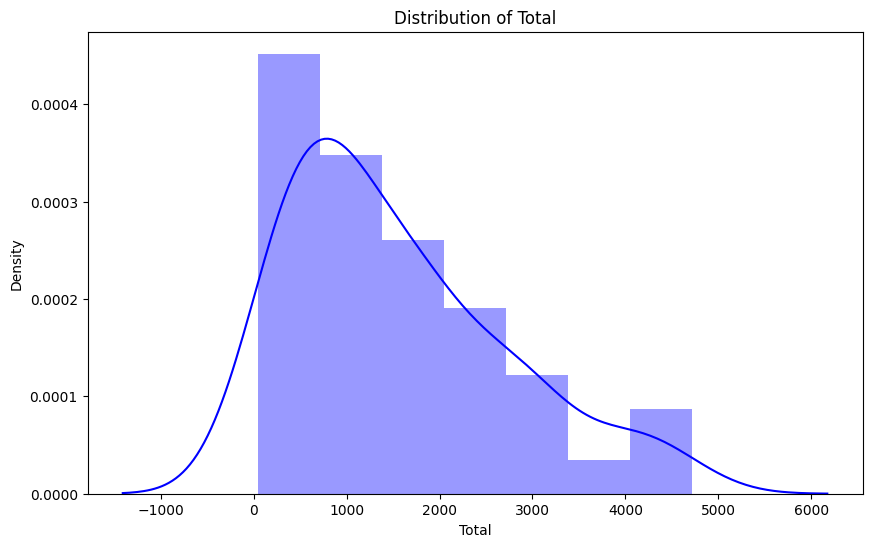

In [ ]:
plt.figure(figsize=(10,6)) #Set the size of the figure
sns.distplot(df['Total'],bins=7,kde=True,color='blue') #Distribution plot of Total
plt.title('Distribution of Total') #Title of the plot
plt.show() #Display of the plot

In [ ]:
category_map = {
    'electronics': 'electronics',
    'electronic': 'electronics',
    'Electronics ': 'electronics',
    'ELECTRONICS':'electronics',
    'Home':'home',
    'Sports':'sports',
    'Books':'books',
    'Clothing':'clothing'

} #Create a dictionary to standardize category names

df[' Category'] = df[' Category'].map(category_map) #Apply mapping to 'Category' column


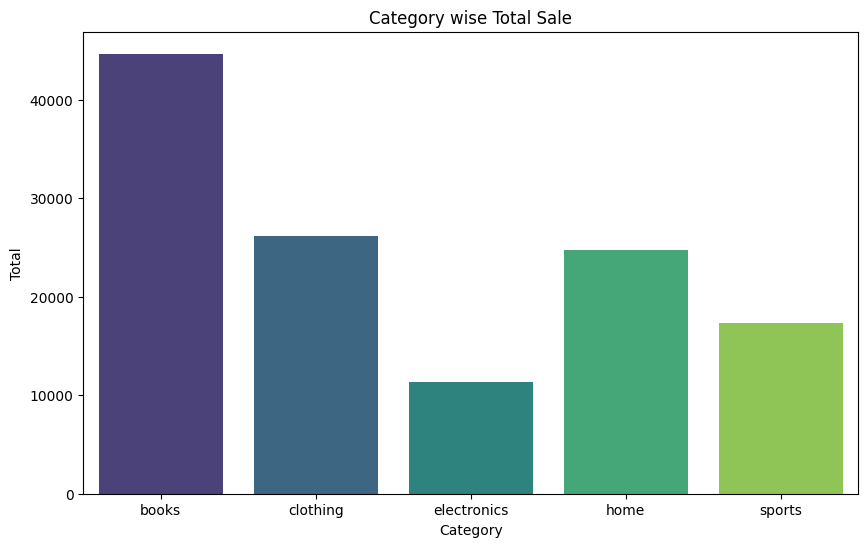

In [ ]:
Category_Wise_Total=df.groupby(' Category')['Total'].sum() #Group data by 'Category' and calculate total sales
plt.figure(figsize=(10,6)) #Set the size of the plot
sns.barplot(x=Category_Wise_Total.index,y=Category_Wise_Total.values,palette='viridis') #Create bar plot by seaborn
plt.xlabel('Category') # x-axis of the plot
plt.ylabel('Total') #y-axis of the plot
plt.title('Category wise Total Sale') #Title of the plot
plt.show()

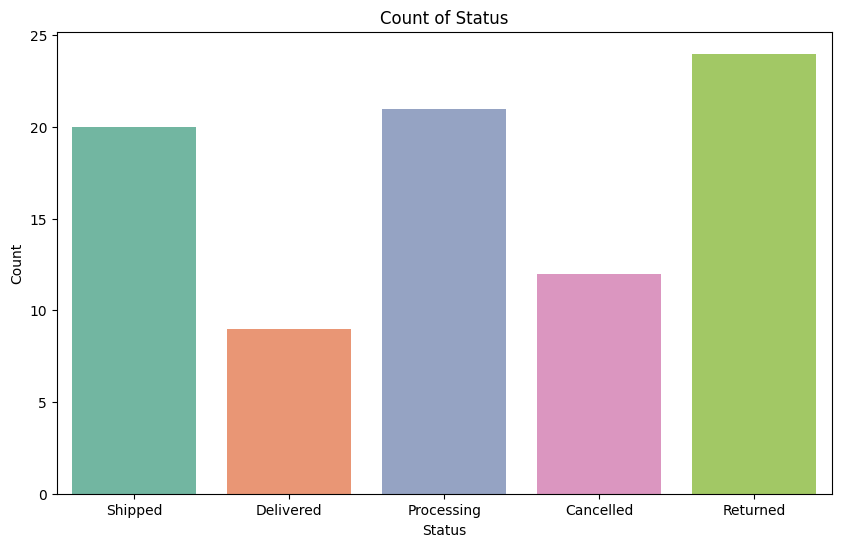

In [ ]:
plt.figure(figsize=(10,6)) #Set the size of the plot
sns.countplot(x=df['Status'],data=df,palette='Set2') # Create a countplot of Status
plt.xlabel('Status') #x-axis of the plot
plt.ylabel('Count') #y-axis of the plot
plt.title('Count of Status') #Title of the plot
plt.show() #Display of the plot


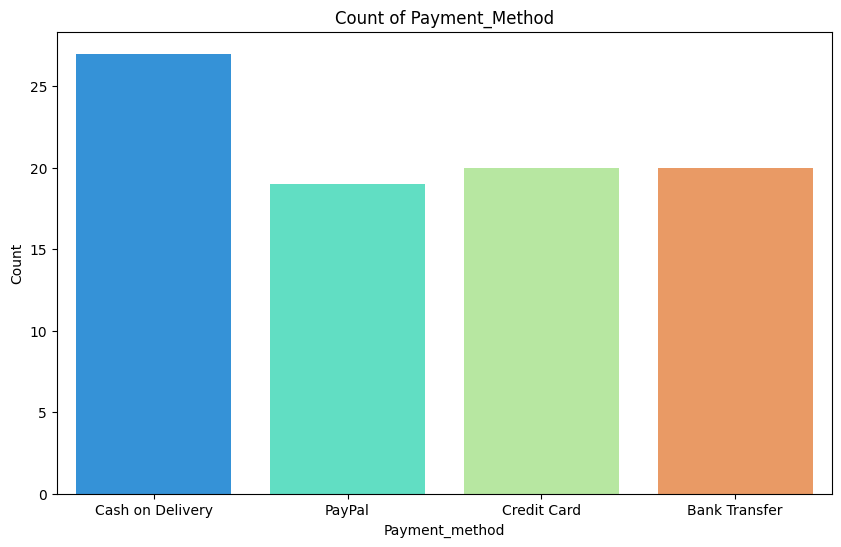

In [ ]:
plt.figure(figsize=(10,6)) #Set the size of the plot
sns.countplot(x=df['Payment_Method'],data=df,palette='rainbow') # Create a counplot by using seaborn
plt.xlabel('Payment_method') #x-axis of the plot
plt.ylabel('Count') #y-axis of the plot
plt.title('Count of Payment_Method') #Title of the plot
plt.show() #Display of the plot

In [ ]:
x=df.drop('Total',axis=1) #Dependent Variables
y=df['Total'] #Target variable
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42) # Split dataset into training and testing sets

In [ ]:
train_data=x_train.copy() #Create a copy of training features
train_data['Total']=y_train #Add target column ('Total') to the copied data
product_mean=train_data.groupby('Product')['Total'].mean() #Calculate mean 'Total' for each Product
x_train['Product_Enc']=x_train['Product'].map(product_mean) #Apply target encoding on training data
x_test['Product_Enc']=x_test['Product'].map(product_mean) #Replace each Product with its corresponding mean Total
global_mean=y_train.mean() #Calculate global mean of target variable
x_train['Product_Enc'].fillna(global_mean, inplace=True) #Fill missing values in encoded column (train)
x_test['Product_Enc'].fillna(global_mean, inplace=True) #Fill missing values in encoded column (test)

# Drop original product column
x_train.drop('Product', axis=1, inplace=True)
x_test.drop('Product', axis=1, inplace=True)

In [ ]:
low_cardinality_columns=[' Category','Payment_Method','Status'] # Define low-cardinality categorical columns
x_train=pd.get_dummies(x_train,columns=low_cardinality_columns,drop_first=True) # Apply one-hot encoding on training data
x_test=pd.get_dummies(x_test,columns=low_cardinality_columns,drop_first=True) #Apply one-hot encoding to test data


,Quantity,Price,Year,Month,Day,Product_Enc,Category_clothing,Category_electronics,Category_home,Category_sports,Payment_Method_Cash on Delivery,Payment_Method_Credit Card,Payment_Method_PayPal,Status_Delivered,Status_Processing,Status_Returned,Status_Shipped
89,1,814,2025,8,14,1753,0,0,1,0,1,0,0,0,0,1,0
0,3,38,2024,11,22,1592,0,0,1,0,1,0,0,0,0,0,1
84,4,101,2025,2,15,3708,0,0,0,0,0,0,0,0,1,0,0
29,4,736,2025,6,22,1011,0,0,0,0,0,0,0,0,0,1,0
15,2,796,2025,1,10,1918,0,0,0,0,1,0,0,0,0,1,0
69,1,582,2025,8,12,1666,0,0,0,1,0,1,0,0,0,1,0
13,1,411,2025,7,24,1918,0,0,0,0,0,1,0,0,1,0,0
25,4,765,2025,2,9,2278,0,0,0,0,0,0,1,0,0,0,1
5,3,122,2024,11,20,827,0,0,0,1,1,0,0,0,0,0,0
80,2,418,2025,3,26,1043,0,0,0,0,0,1,0,0,1,0,0


In [ ]:
x_train, x_test = x_train.align(x_test, join='left', axis=1, fill_value=0) #Align columns of training and testing data
x_train = x_train.astype(int) #Convert all values in x_train to integer type
x_test = x_test.astype(int) #Convert all values in x_test to integer type

In [ ]:
model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
) #Initialize XGBoost Regressor model

model.fit(x_train, y_train) #Fit the model

# Predict
y_pred = model.predict(x_test) #Predict the model

In [ ]:
print("R2:", r2_score(y_test, y_pred)) #Calculate and print R² score
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred))) #Calculate RMSE (Root Mean Squared Error)

R2: 0.9657689474928915
RMSE: 264.5301459923702


In [ ]:
cv_scores = cross_val_score(model, x_train, y_train, cv=5, scoring='r2') #Perform 5-fold cross-validation on training data
print("CV R2:", np.mean(cv_scores)) #Calculate and print average R² across all folds

CV R2: 0.8680592883555418


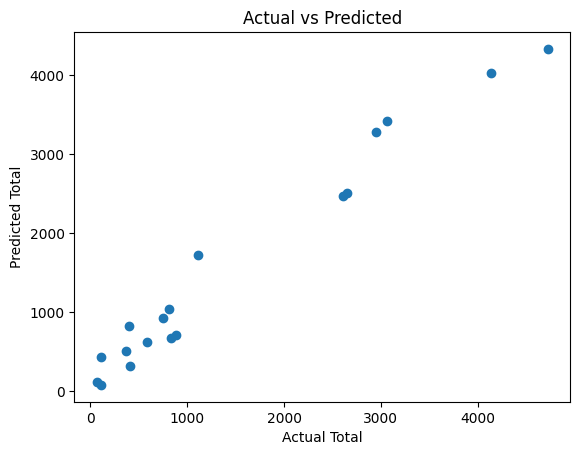

In [ ]:
plt.scatter(y_test, y_pred) #Create a scatter plot to compare actual vs predicted values
plt.xlabel("Actual Total") #Label X-axis
plt.ylabel("Predicted Total") #Label Y-axis
plt.title("Actual vs Predicted") #Title of the plot
plt.show() #Display of the plot